cos:  1.0
q = 0.024525
D = 6159152.500615914
maxh: 20
min w [mm]        = -3.112270211274727
max w [mm]        = 0.008823262263580161
max z-Abstand [mm]= 3.1210934735383074
max |w| [mm]      = 3.112270211274727
Scale in Visualization:  100


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

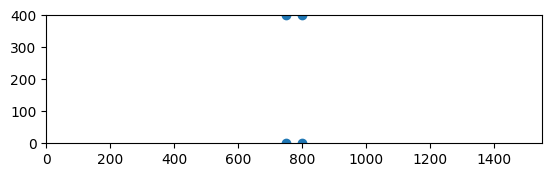

In [7]:
from ngsolve import *
from netgen.geom2d import SplineGeometry
import netgen.gui
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
from ngsolve import x,y
from netgen.occ import *
from math import pi, cos
from ngsolve.fem import NODE_TYPE
from ngsolve.meshes import MakeStructured2DMesh

"""
15.5 
aktuelle Variationsformulierung (wie in ngSolve)
Reissner Mindlin ohne TDNNS
nearest Vertex -> freeDofs = 0
"""

#PUNKT RAND/AUFLAGER
def ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,AuflagerListe,scale=1,step=40,maxh=8,Neigungsfaktor_cos=1):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho * g * Neigungsfaktor_cos
    D = E/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G/t**2                     # Schubsteifigkeit
    # A = E*t/(1-nu**2)              # Membransteifigkeit
    print("q =", q)
    print("D =", D)
    #endregion

    #region GEOMETRIE
    shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()
    shape.edges.name="free"
    rect = shape 
    geo = OCCGeometry(rect,dim=2)
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))

    mesh.Curve(3)
    #endregion

    #region FEM-Räume
    order = 2
    Vw = H1(mesh, order=order)      # Durchbiegung
    Vb = VectorH1(mesh, order=order)    # Rotation
    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #endregion
    
    #region FEM
    a = BilinearForm(X, symmetric=True)
    # Biegung
    a += D * ((1-nu)*InnerProduct(Sym(Grad((beta))), Sym(Grad((eta)))) + nu*Trace(Sym(Grad((beta))))*Trace(Sym(Grad((eta))))) * dx
    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    f = LinearForm(X)
    f += -q * v/(t**2) * dx

    a.Assemble()
    f.Assemble()

    import numpy as np
    # Nearest_Vertex_ID Liste basteln
    meshPunkte = mesh.vertices      # holen uns die Menge aller Punkte aus unserem Mesh
    anzahl_auflager = len(AuflagerListe)
    Nearest_Vertex_ID = np.zeros(anzahl_auflager)       # speichert jeweils für alle AuflagerPunkte den nächsten meshPunkt
    for i,punkt in enumerate(AuflagerListe):
        distances = [np.linalg.norm( np.array(mPunkt.point) - punkt ) for mPunkt in meshPunkte]
        # print([mPunkt.point for mPunkt in meshPunkte])
        vertexNr = np.argmin(distances)
        Nearest_Vertex_ID[i] = vertexNr

    free_dofs = X.FreeDofs()        # holt alle Freiheitsgrade
    # Q_offset = Vw.ndof

    for vertexNummer in Nearest_Vertex_ID.astype(int):
        for dof in Vw.GetDofNrs(NodeId(NODE_TYPE.VERTEX, vertexNummer)):
            free_dofs[dof] = False
            # free_dofs[Q_offset + dof] = False

    gf.vec[:] = 0
    # gfu.vec.data = a.mat.Inverse(free_dofs) * f.vec
    gf.vec[:] = a.mat.Inverse(freedofs=free_dofs) * f.vec
    # Draw(w, mesh,euler_angles=[-60,-10,-20], deformation=True, scale=scale);

    print("maxh:",maxh)
    # print("min w [mm] =", min(w.vec.FV().NumPy()))

    w_values = w.vec.FV().NumPy()

    w_min = np.min(w_values)
    w_max = np.max(w_values)
    w_diff = w_max - w_min
    w_abs_max = np.max(np.abs(w_values))

    print("min w [mm]        =", w_min)
    print("max w [mm]        =", w_max)
    print("max z-Abstand [mm]=", w_diff)
    print("max |w| [mm]      =", w_abs_max)

    print("Scale in Visualization: ",scale)

    Draw(w, mesh,deformation=True,euler_angles=[-60,5,30],settings={'Objects': {'Vectors': False, 'Wireframe': False, 'Surface': True}},scale=scale)

    # Draw(w,mesh,deformation=True,euler_angles=[-60,5,30],scale=scale)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, z_w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{z_w:.2f}\n")

    import matplotlib.pyplot as plt

    xs = [x[0] for x in AuflagerListe]
    ys = [x[1] for x in AuflagerListe]
    plt.scatter(xs, ys)
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion

    return filename_GRAV


if __name__ =='__main__':
    Lx = 1550
    Ly = 400
    t  = 8               # Dicke
    step = 40           # Anzahl gespeicherter Punkte in x/y-Richtung im xyz-File

    scale = 100        # für den NGSolve-Plot
    maxh = 20           # die Dichtheit des Mesh    

    Neigungswinkel_grad = 0 # Gradz
    Neigungswinkel_rad = Neigungswinkel_grad * pi/180
    Neigungsfaktor_cos = cos(Neigungswinkel_rad)
    print("cos: ",Neigungsfaktor_cos)

    #PUNKT-AUFLAGER
    dosen_radius = 25 #mm
    # supports = [(dosen_radius,dosen_radius), (dosen_radius,Ly-dosen_radius), (Lx-dosen_radius,dosen_radius), (Lx-dosen_radius,Ly-dosen_radius)] # supports1
    supports = [(Lx/2 - dosen_radius,0),(Lx/2 - dosen_radius,Ly), (Lx/2 + dosen_radius,0),(Lx/2 + dosen_radius,Ly)] # supports2
    # supports = [(Lx/2 - 3*dosen_radius,0),(Lx/2 - 3*dosen_radius,Ly), (Lx/2 + 3*dosen_radius,0),(Lx/2 + 3*dosen_radius,Ly)]       # supports3
    # supports = [(0,0),(0,Ly),(Lx/2,Ly/2)]

    # supports = [(0,0),(0,Ly),(Lx,0),(Lx,Ly)]
    
    # supports = [(2/10*Lx,Ly*8/10), (8/10*Lx,Ly*8/10), (2/10*Lx,Ly*2/10),(8/10*Lx,Ly*2/10)]
    ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,supports,scale,step,maxh,Neigungsfaktor_cos)

